### This notebook performs EDA to understand how factors like gender, lunch, parental education level, etc.. influence student's performance in test


### Dataset
- Source: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- Columns: 8 
- Rows: 1000

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("StudentsPerformance.csv")

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Lets try to first understand the data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
# See if we have any missing value for given columns
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## As we can see there are no missing values in our dataset

In [7]:
cat_features = df.select_dtypes(include="object").columns


In [8]:
for col in cat_features:
    print(f'Category in {col} column:',df[col].unique(), end=" \n")
    print("------------------------------------------------------------------")

Category in gender column: ['female' 'male'] 
------------------------------------------------------------------
Category in race/ethnicity column: ['group B' 'group C' 'group A' 'group D' 'group E'] 
------------------------------------------------------------------
Category in parental level of education column: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school'] 
------------------------------------------------------------------
Category in lunch column: ['standard' 'free/reduced'] 
------------------------------------------------------------------
Category in test preparation course column: ['none' 'completed'] 
------------------------------------------------------------------


## By the above output we can uderstand that: 
1) In parental level of education: there is [high school] and [some high school] both are refering to the same thing, thus we can merge them
2) For columns like: [lunch], [gender], [race/ethnicity], [test preperation] we can encode the very easily 
3) from [math score], [reading score], [writing score] we can create 2 new columns which are: [total_score] and [average_score]

In [9]:
df["total_score"] = df["reading score"] + df["writing score"] + df["math score"]

In [10]:
df["average_score"] = df["total_score"]/3

In [11]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### we can keep [writing score], [reading score], [math score] or drop them, in our case lets proceed with keeping them- for extra information

In [12]:
df["parental level of education"] = np.where(df["parental level of education"] == "some high school","high school", df["parental level of education"] )

In [13]:
df["parental level of education"].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school'], dtype=object)

In [14]:
df.nunique()

gender                           2
race/ethnicity                   5
parental level of education      5
lunch                            2
test preparation course          2
math score                      81
reading score                   72
writing score                   77
total_score                    194
average_score                  194
dtype: int64

### Data Checks performed till now

- Check Missing values
- Check data type
- Check the number of unique values of each column
- Check various categories present in the different categorical column

### Data Checks to perform

- Check Duplicates
- Check statistics of data set


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,math score,reading score,writing score,total_score,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000


In [17]:
numeric_features = df.select_dtypes(include="number").columns
cat_features = df.select_dtypes(include="object").columns


In [18]:
print("Total number of numeric columns:", len(numeric_features))
print("Total number of categorical columns:",len(cat_features))

Total number of numeric columns: 5
Total number of categorical columns: 5


In [19]:
df.head(
    
)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [20]:
full_in_reading = (df['reading score'] == 100).sum()
full_in_maths = (df['math score'] == 100).sum()
full_in_writing = (df['writing score'] == 100).sum()

In [21]:
print("Number of student scored full marks in Reading", full_in_reading)
print("Number of student scored full marks in Writing", full_in_writing)
print("Number of student scored full marks in Maths", full_in_maths)

Number of student scored full marks in Reading 17
Number of student scored full marks in Writing 14
Number of student scored full marks in Maths 7


In [22]:
less_20_in_reading = (df['reading score'] <= 20).sum()
less_20_in_maths = (df['math score'] <= 20 ).sum()
less_20_in_writing = (df['writing score'] <= 20).sum()

In [23]:
print("Number of student scored less than 20 marks in Reading", less_20_in_reading)
print("Number of student scored less than 20  marks in Writing", less_20_in_writing)
print("Number of student scored less than 20  marks in Maths", less_20_in_maths)

Number of student scored less than 20 marks in Reading 1
Number of student scored less than 20  marks in Writing 3
Number of student scored less than 20  marks in Maths 4


## Visualization

<Axes: xlabel='average_score', ylabel='Count'>

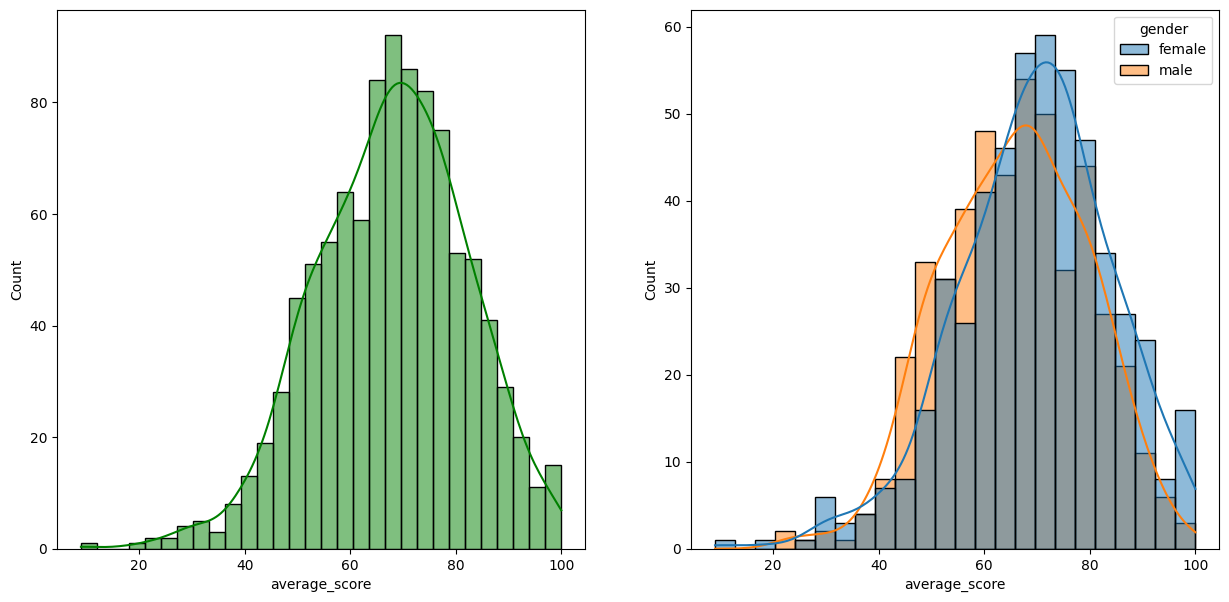

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='average_score', kde=True, bins=30, color='g')
plt.subplot(122)
sns.histplot(data=df, x="average_score", kde=True, hue='gender')
plt.show()

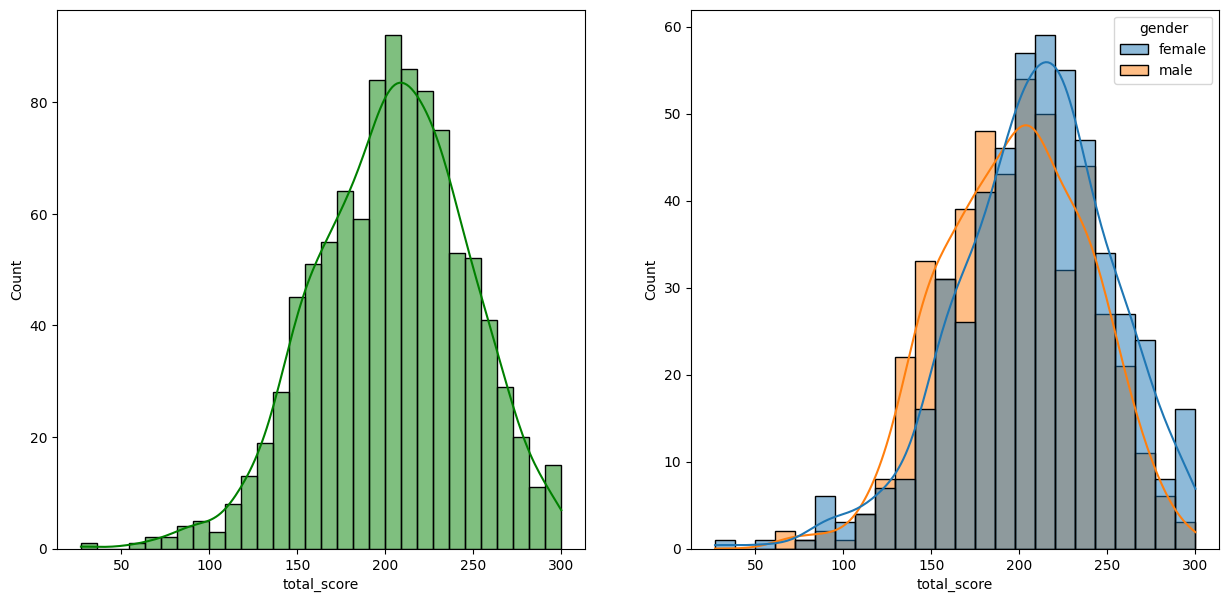

In [30]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='total_score', kde=True, bins=30, color='g')
plt.subplot(122)
sns.histplot(data=df, x="total_score", kde=True, hue='gender')
plt.show()

## Insight
- Female students tend to perform better than male students

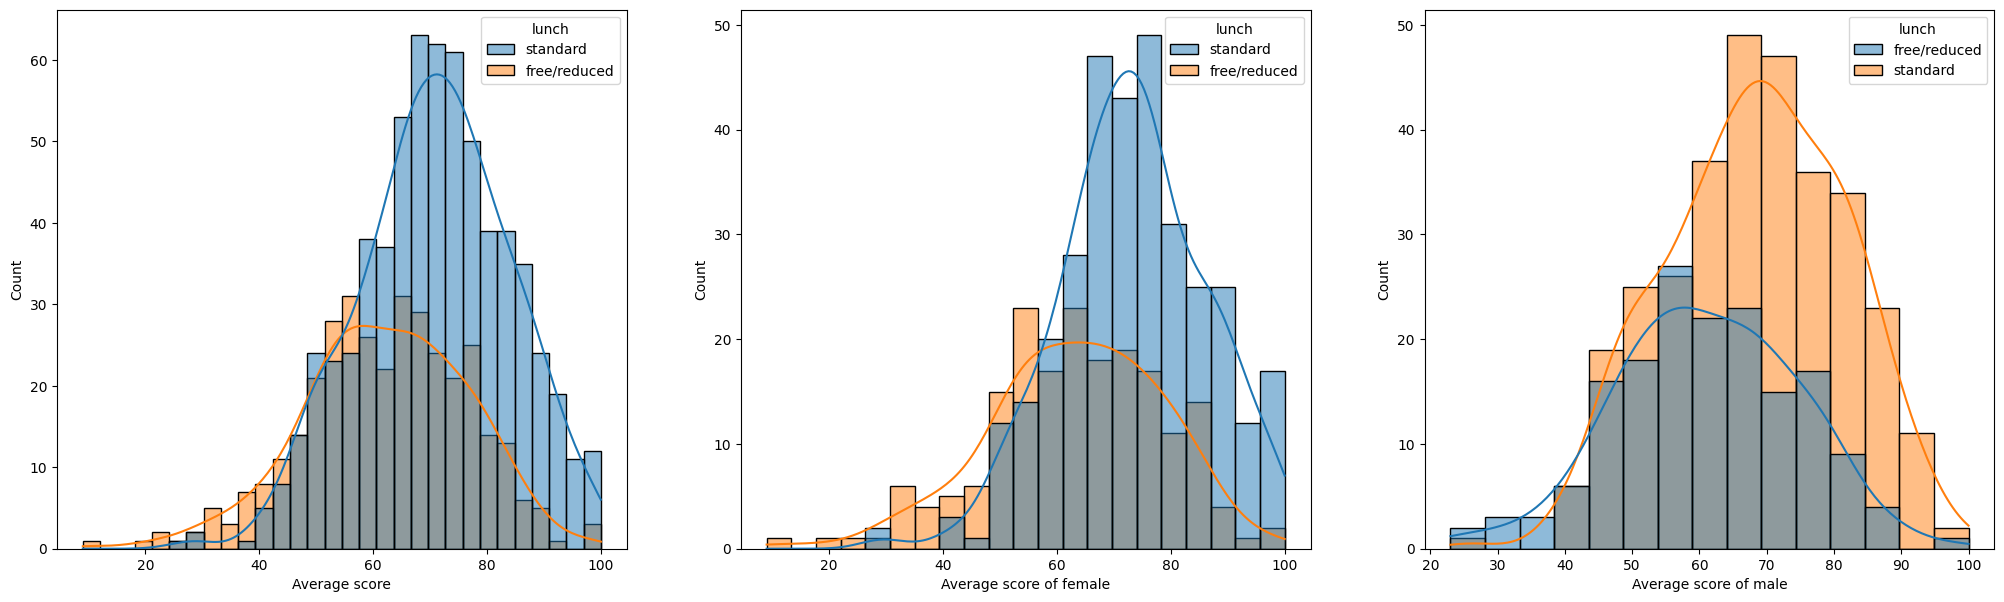

In [36]:
fig, axs = plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df, x='average_score', kde=True, bins=30, hue="lunch")
plt.xlabel("Average score")
plt.subplot(132)
sns.histplot(data=df[df["gender"]=="female"], x="average_score", kde=True, hue='lunch')
plt.xlabel("Average score of female")
plt.subplot(133)
sns.histplot(data=df[df["gender"]== "male"], x="average_score", kde=True, hue='lunch')
plt.xlabel("Average score of male")
plt.show()

# Insight:
- Standard lunch help score better for both male and female

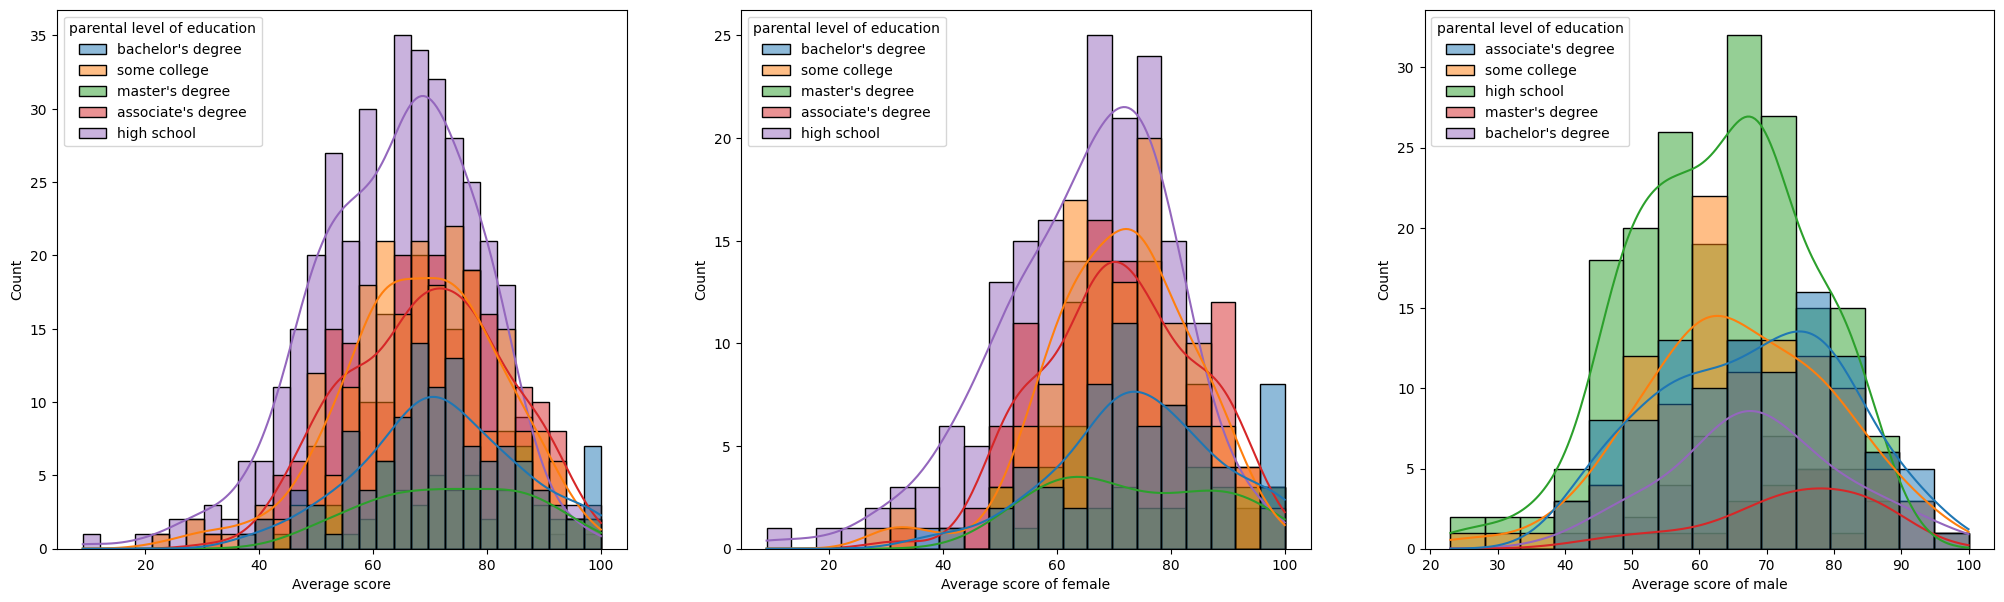

In [37]:
fig, axs = plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df, x='average_score', kde=True, bins=30, hue="parental level of education")
plt.xlabel("Average score")
plt.subplot(132)
sns.histplot(data=df[df["gender"]=="female"], x="average_score", kde=True, hue='parental level of education')
plt.xlabel("Average score of female")
plt.subplot(133)
sns.histplot(data=df[df["gender"]== "male"], x="average_score", kde=True, hue='parental level of education')
plt.xlabel("Average score of male")
plt.show()

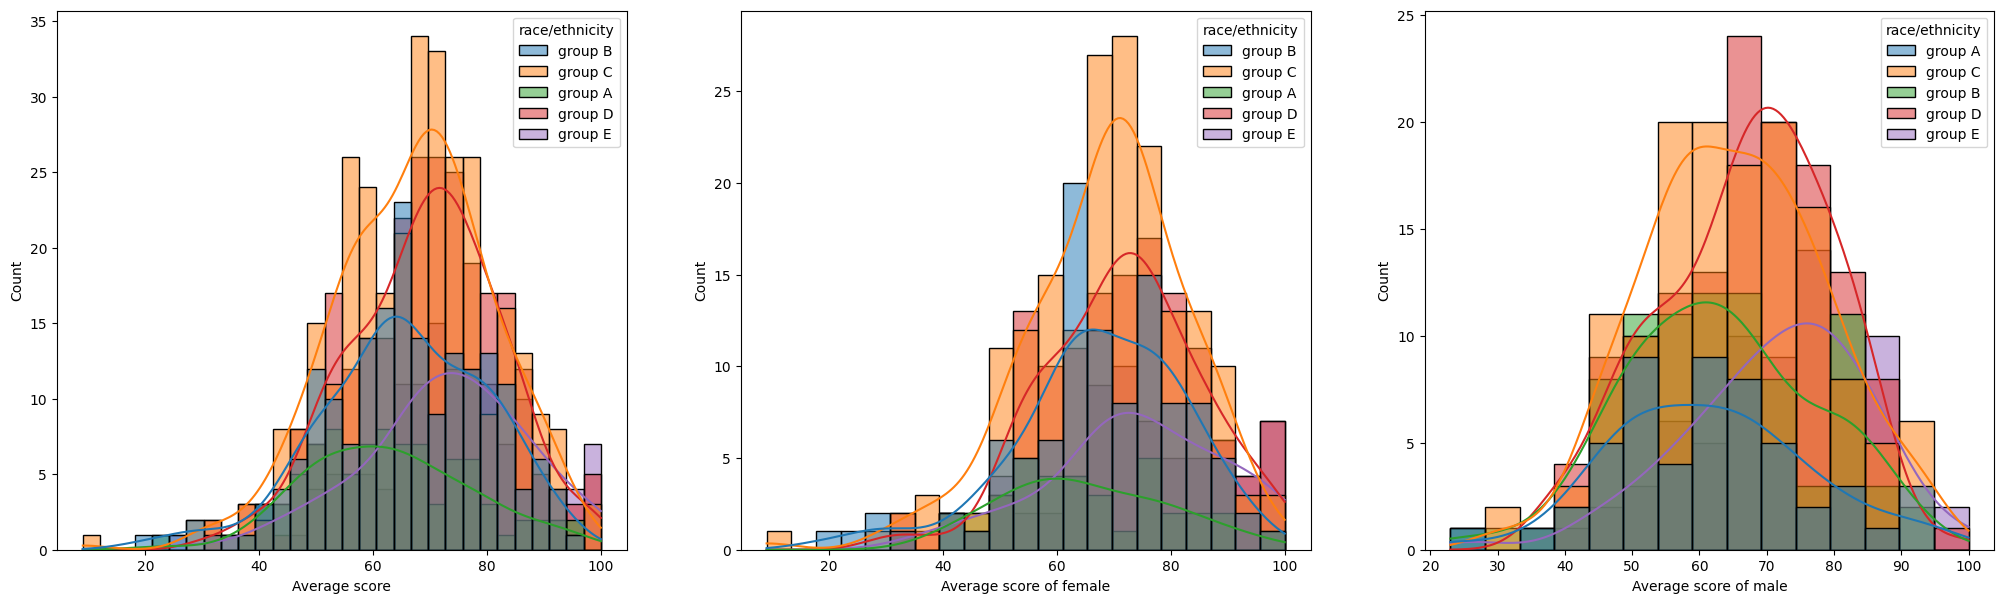

In [69]:
fig, axs = plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df, x='average_score', kde=True, bins=30, hue="race/ethnicity")
plt.xlabel("Average score")
plt.subplot(132)
sns.histplot(data=df[df["gender"]=="female"], x="average_score", kde=True, hue='race/ethnicity')
plt.xlabel("Average score of female")
plt.subplot(133)
sns.histplot(data=df[df["gender"]== "male"], x="average_score", kde=True, hue='race/ethnicity')
plt.xlabel("Average score of male")
plt.show()

## Insights
- Group A and Group E tend to perform poorly in test regardless of their gender
- Group C performs better overall
- In male Group D perform better 
- In female Group c perform better


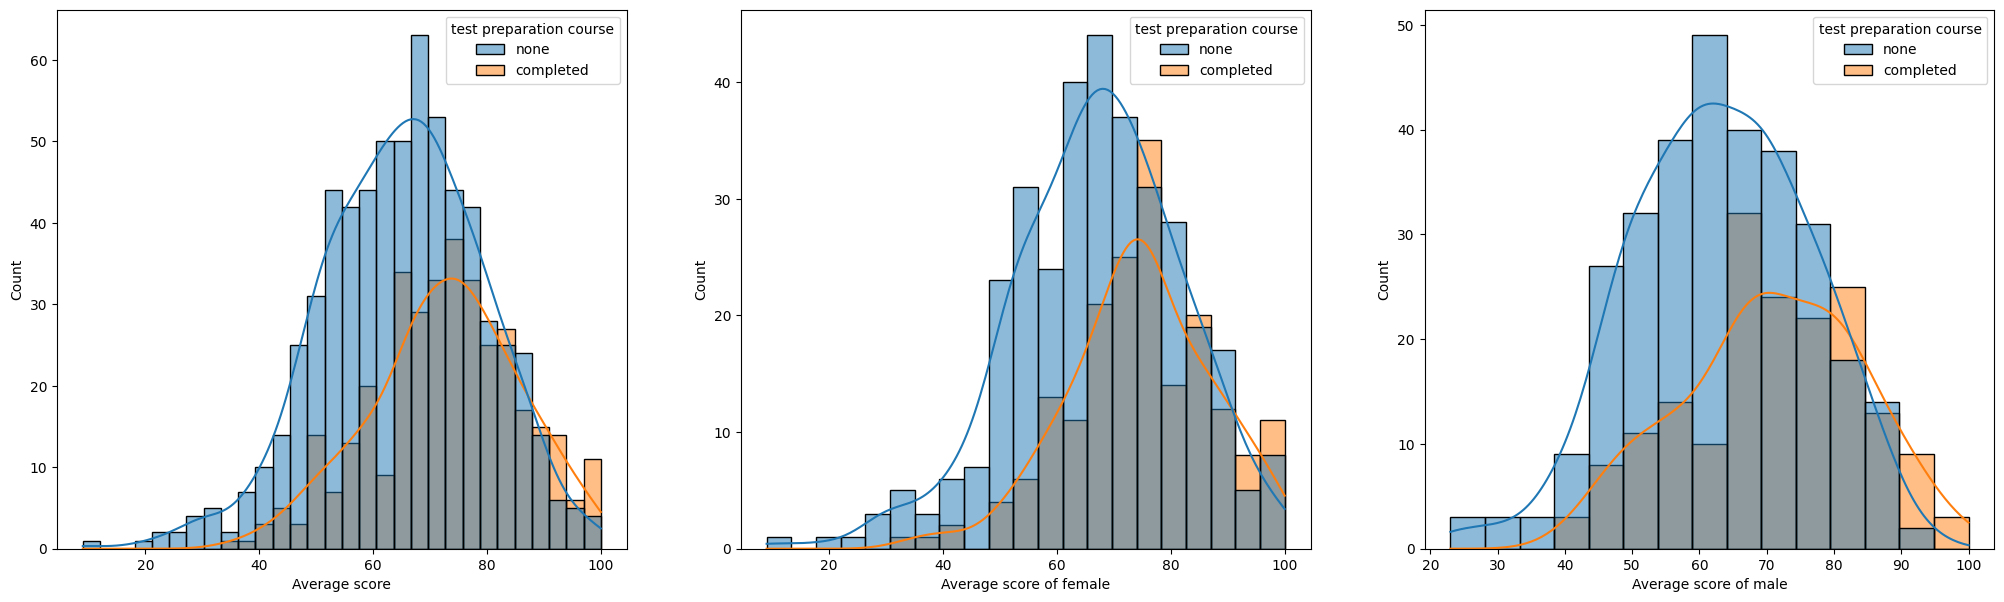

In [73]:
fig, axs = plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df, x='average_score', kde=True, bins=30, hue="test preparation course")
plt.xlabel("Average score")
plt.subplot(132)
sns.histplot(data=df[df["gender"]=="female"], x="average_score", kde=True, hue='test preparation course')
plt.xlabel("Average score of female")
plt.subplot(133)
sns.histplot(data=df[df["gender"]== "male"], x="average_score", kde=True, hue='test preparation course')
plt.xlabel("Average score of male")
plt.show()

# Insight:
- Student who have taken some kind of test preparation course tend to perform better than those who have not, this is true for both male and female

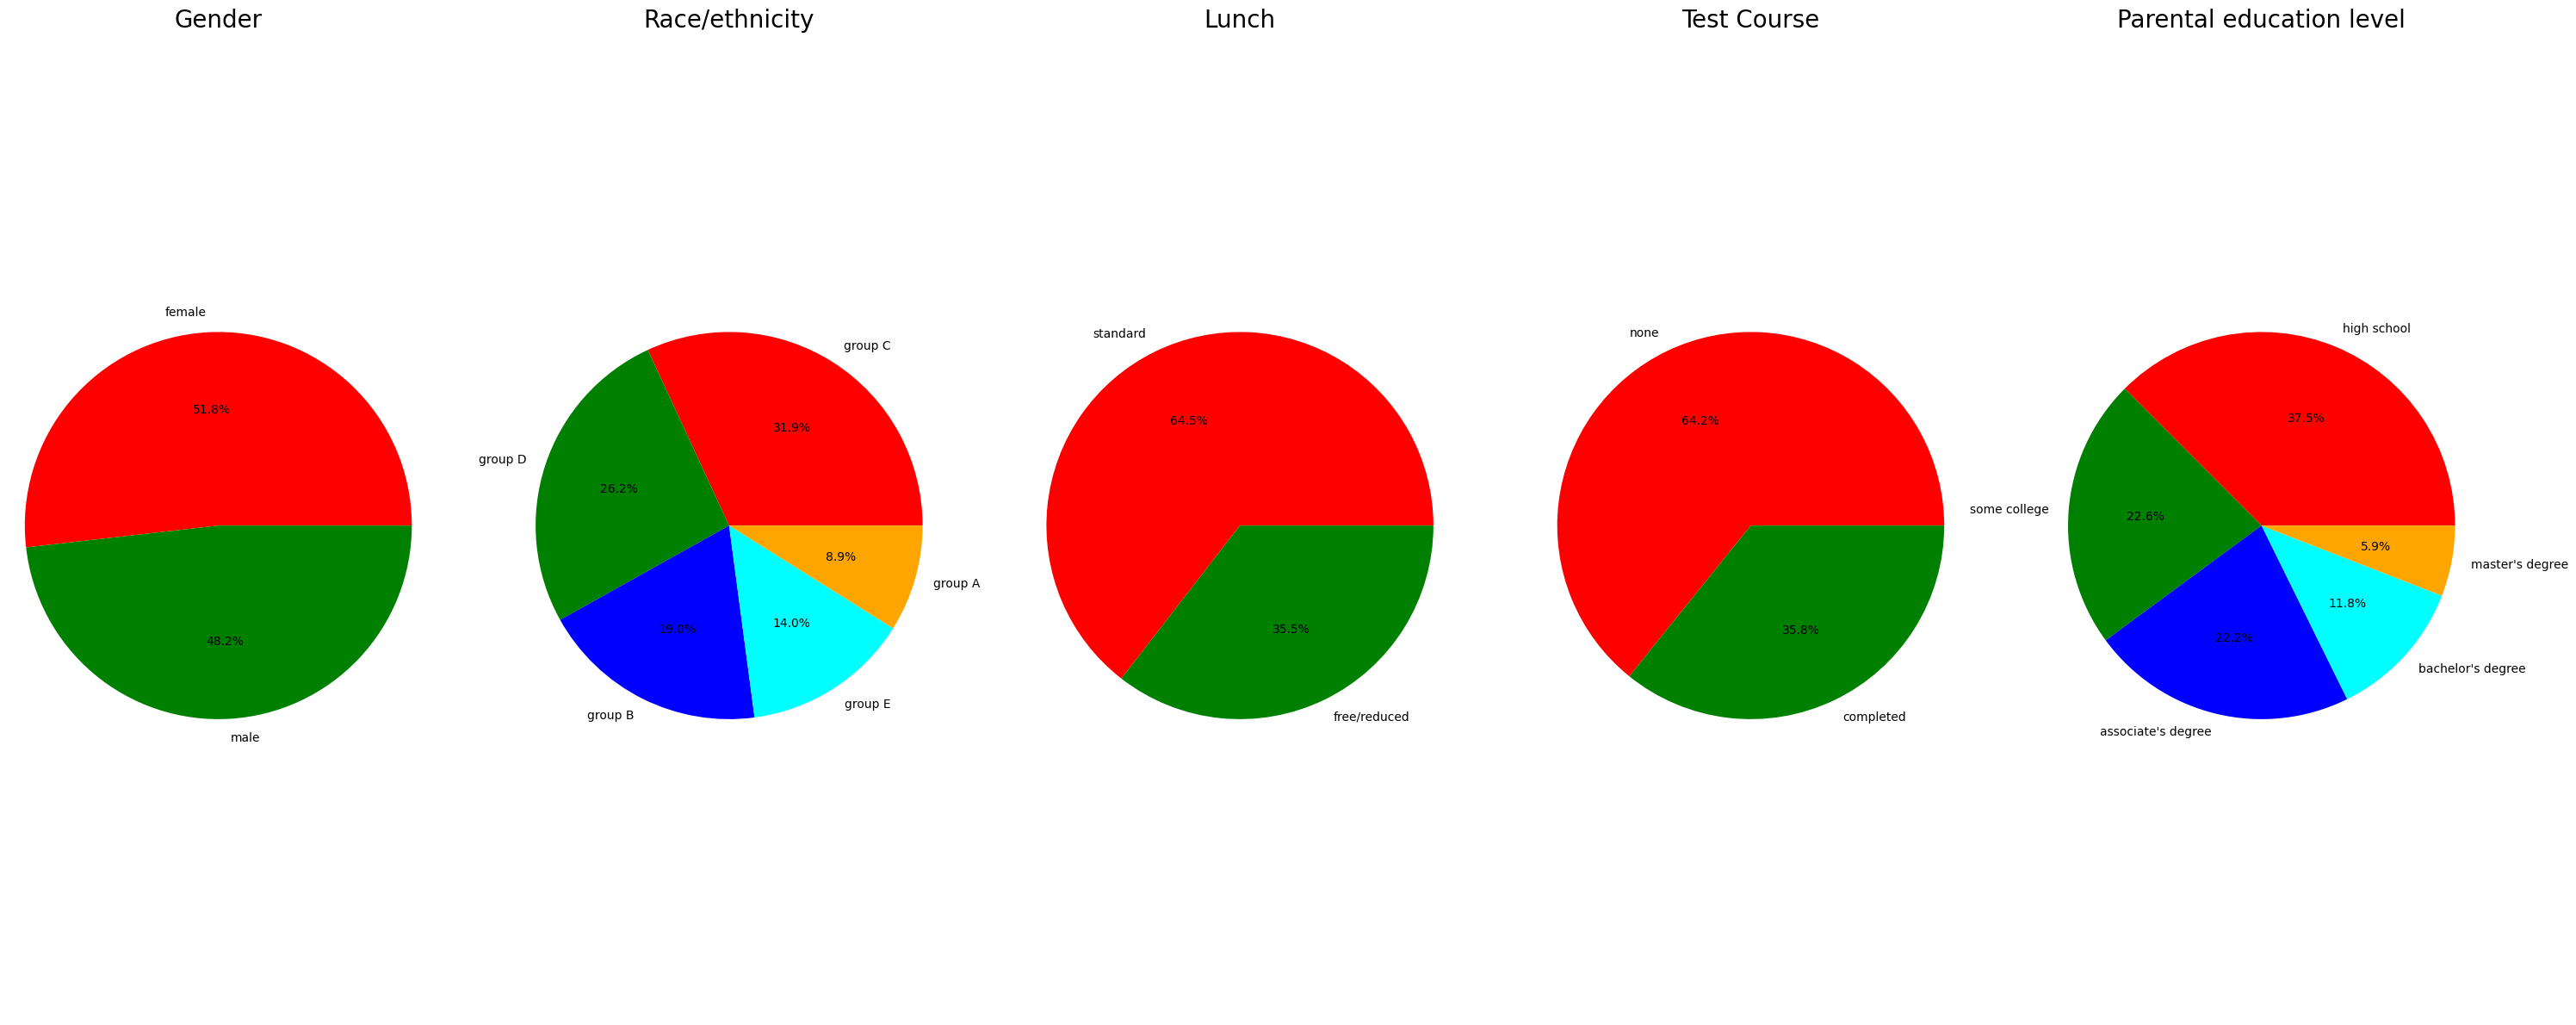

In [74]:
plt.rcParams['figure.figsize'] = (30,12)


plt.subplot(1,5,1)
size = df["gender"].value_counts()

color = ['red', 'green']
plt.pie(size, colors=color, labels=size.index, autopct= '%.1f%%')
plt.title("Gender", fontsize=20)
plt.axis('off')
plt.axis('equal')


plt.subplot(1,5,2)
size = df["race/ethnicity"].value_counts()

color = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors=color, labels=size.index, autopct= '%.1f%%')
plt.title("Race/ethnicity", fontsize=20)
plt.axis('off')
plt.axis('equal')


plt.subplot(1,5,3)
size = df["lunch"].value_counts()

color = ['red', 'green']
plt.pie(size, colors=color, labels=size.index, autopct= '%.1f%%')
plt.title("Lunch", fontsize=20)
plt.axis('off')
plt.axis('equal')



plt.subplot(1,5,4)
size = df["test preparation course"].value_counts()

color = ['red', 'green']
plt.pie(size, colors=color, labels=size.index, autopct= '%.1f%%')
plt.title("Test Course", fontsize=20)
plt.axis('off')
plt.axis('equal')


plt.subplot(1,5,5)
size = df["parental level of education"].value_counts()

color = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors=color, labels=size.index, autopct= '%.1f%%')
plt.title("Parental education level", fontsize=20)
plt.axis('off')
plt.axis('equal')

plt.tight_layout()
plt.show()


# Insights
- Number of male and female student are almost same
- Number of student in group C are highest
- Number of student who take standard lunch are more
- Number of student who are NOT enrolled in any test are higher
- Number of student whose parents education level is "high school" are highest followed by "Some college"


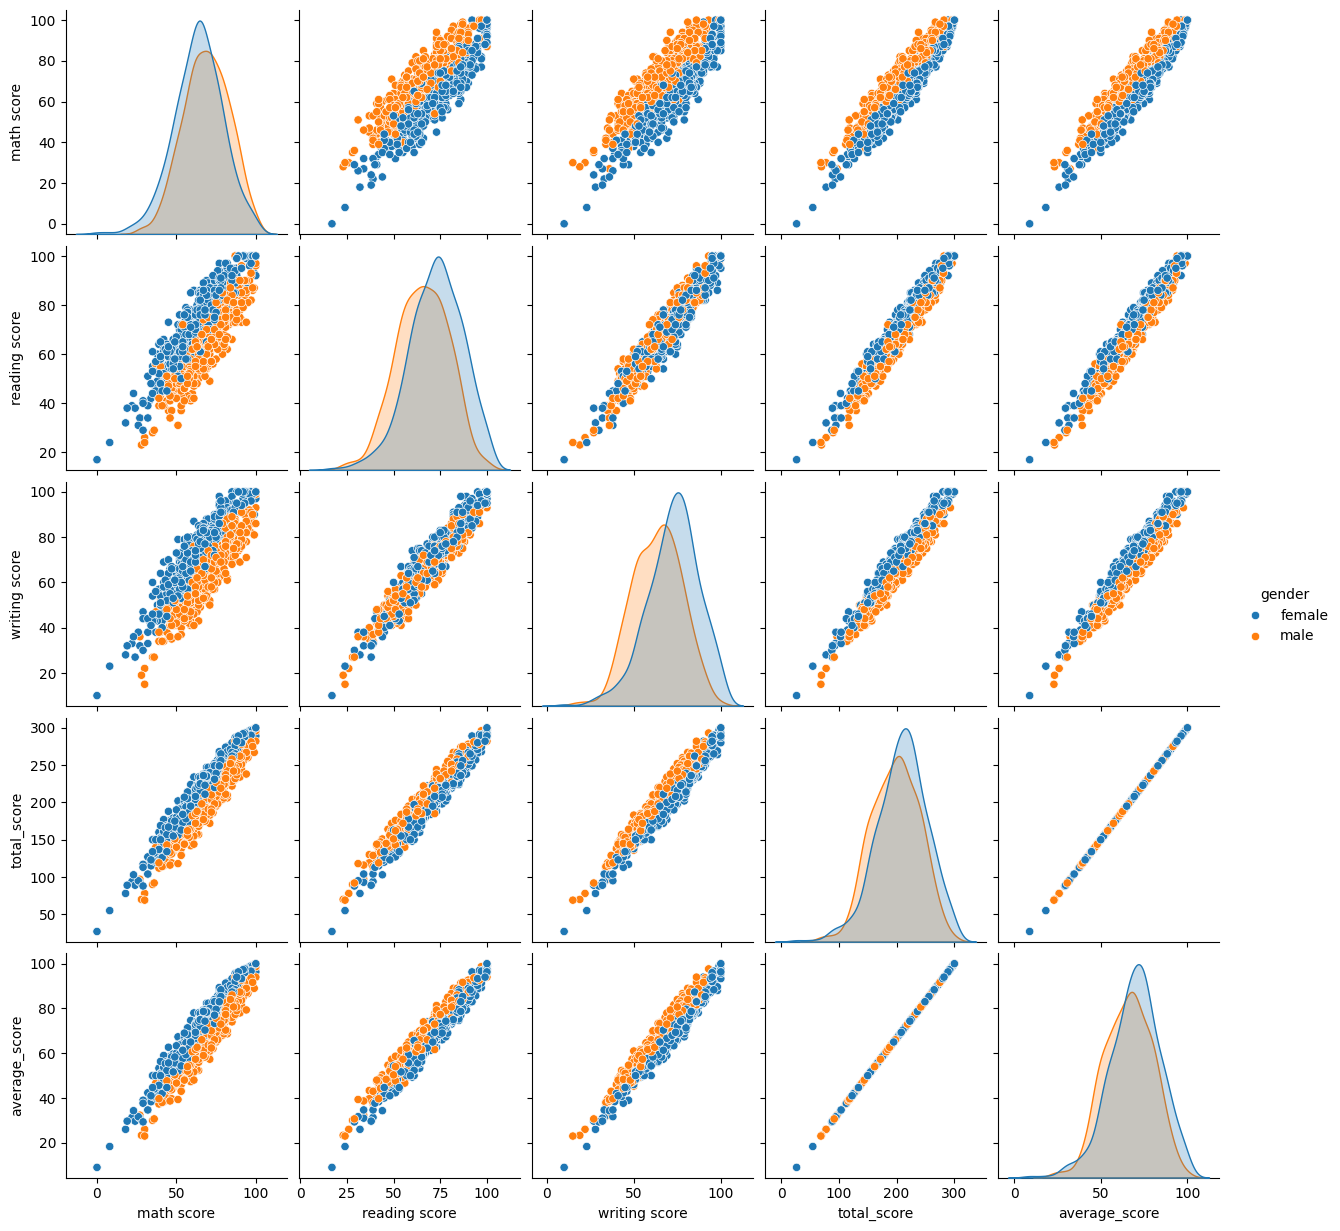

In [75]:
sns.pairplot(df,hue = 'gender')
plt.show()

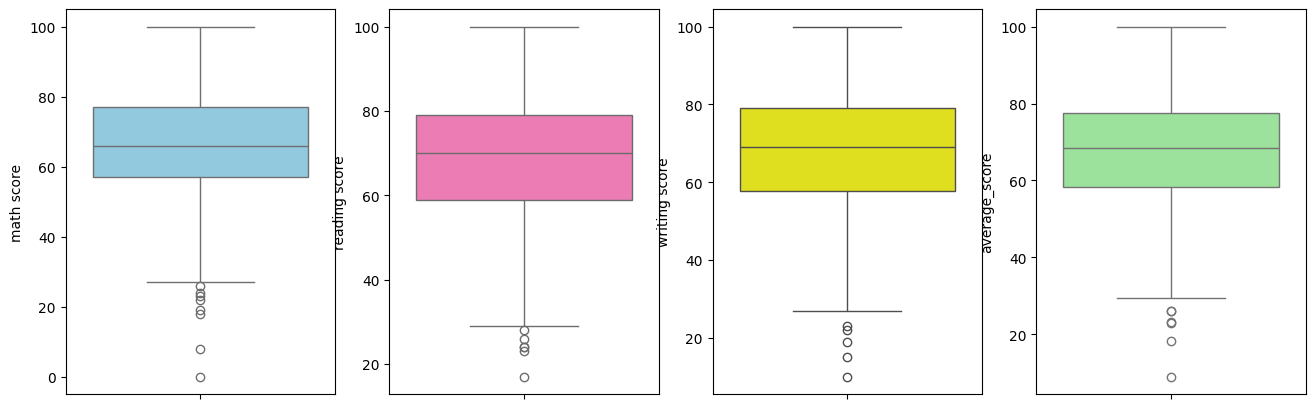

In [79]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

In [78]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [ ]:
! git add .